# Task 2: Credit Risk Prediction

## Objective
Predict whether a loan applicant is likely to default on a loan using classification models.

## Dataset
Loan Prediction Dataset from Kaggle — contains applicant information such as income,
loan amount, education, and credit history.

In [30]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [31]:
# Load the dataset
df = pd.read_csv('train.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [32]:
# Check for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [33]:
# Fill missing values

# Categorical columns → fill with mode (most frequent value)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Numerical columns → fill with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

# Confirm no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


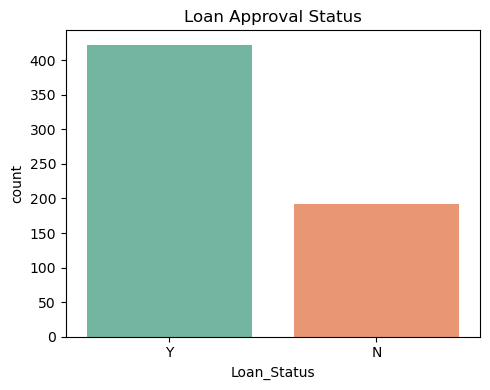

In [34]:
# Plot 1: Loan Status Count
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Loan_Status', palette='Set2')
plt.title('Loan Approval Status')
plt.tight_layout()
plt.savefig('loan_status.png')
plt.show()

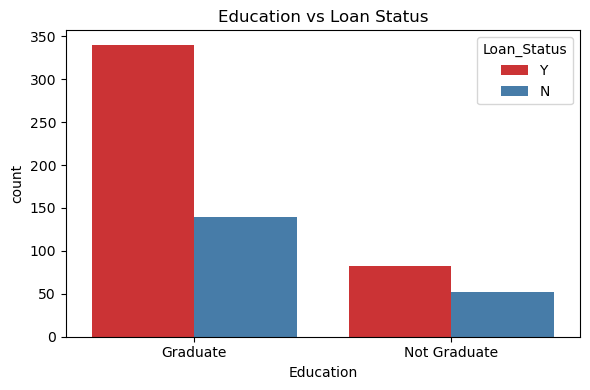

In [35]:
# Plot 2: Education vs Loan Status
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set1')
plt.title('Education vs Loan Status')
plt.tight_layout()
plt.savefig('education_vs_loan.png')
plt.show()

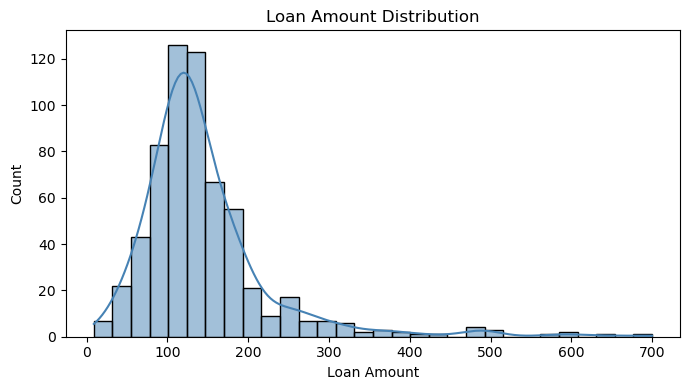

In [36]:
# Plot 3: Loan Amount Distribution
plt.figure(figsize=(7, 4))
sns.histplot(df['LoanAmount'], bins=30, kde=True, color='steelblue')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.tight_layout()
plt.savefig('loan_amount_dist.png')
plt.show()

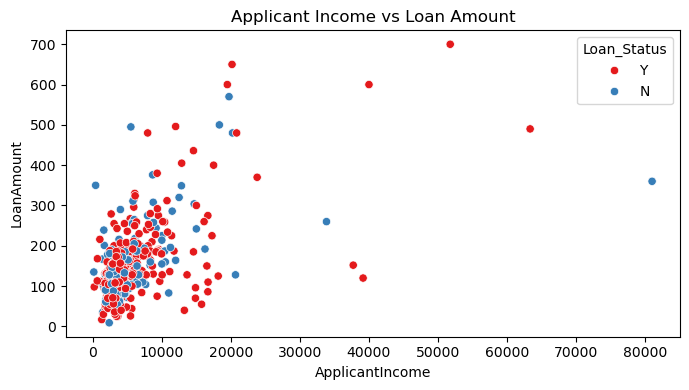

In [37]:
# Plot 4: Applicant Income vs Loan Amount
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', palette='Set1')
plt.title('Applicant Income vs Loan Amount')
plt.tight_layout()
plt.savefig('income_vs_loan.png')
plt.show()

In [38]:
# Convert text columns to numbers using LabelEncoder
le = LabelEncoder()

categorical_cols = ['Gender', 'Married', 'Dependents', 'Education',
                    'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding done! Sample data:")
df.head()

Encoding done! Sample data:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [39]:
# Define features (X) and target (y)
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (491, 11)
Testing set size: (123, 11)


In [40]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Accuracy: 78.86 %

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [41]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Evaluate
print("=== Decision Tree ===")
print("Accuracy:", round(accuracy_score(y_test, dt_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

=== Decision Tree ===
Accuracy: 69.11 %

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123



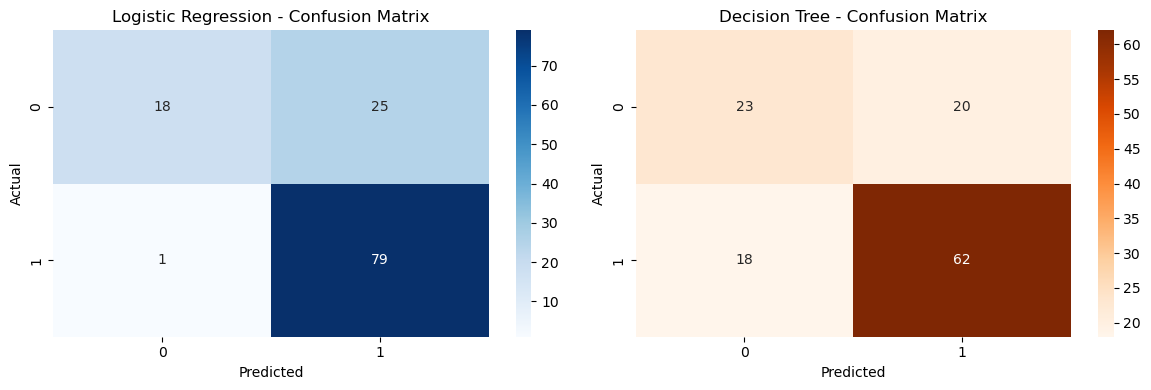

In [42]:
# Confusion Matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree
sns.heatmap(confusion_matrix(y_test, dt_pred),
            annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Decision Tree - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

## Conclusion

- The dataset had missing values in columns like Gender, LoanAmount, and Credit_History — all handled appropriately.
- **Credit History** was found to be the most important factor in loan approval.
- **Logistic Regression** performed better than Decision Tree on this dataset.
- Graduates with good credit history had significantly higher loan approval rates.
- The confusion matrix shows the model predicts loan approvals more accurately than rejections.